# 데이터 직무 연봉 분석 — 재검증 및 재구축

`ds_salaries.csv`를 이용해 데이터 관련 직무의 연봉을 **설명**하고 **예측**한다.

---

## 이 노트북의 성격

이 프로젝트는 원래 팀 과제로 진행됐고, 그 결과물이 `MachineLearning_Team5.ipynb`다.
시간이 지난 뒤 **그 분석을 다시 열어 검증(audit)했더니 결론을 바꿔야 할 문제들이 나왔다.**
이 노트북은 그 검증 과정과, 검증 결과에 따라 다시 세운 분석을 담는다.

기존 분석에서 확인된 문제는 네 가지다.

| # | 문제 | 기존 분석 | 이 노트북에서 확인한 사실 |
| --- | --- | --- | --- |
| 1 | **리키지 규정 오류** | "`salary_currency`는 타겟 누수라서 제외" | `salary_currency` 단독은 누수가 **아니다**. `company_location`과 중복되는 변수였다 (§2) |
| 2 | **이상치 삭제** | IQR로 10건 제거 | 10건 전부 미국의 실존 고위직. 설명 대상 자체를 지운 것 (§3) |
| 3 | **단일 분할 신뢰** | "R²≈0.43", "정확도 0.68" 단일 숫자 보고 | seed만 바꿔도 R²가 0.22~0.65로 요동 (§6) |
| 4 | **베이스라인 부재** | 모델 성능만 보고 | 2변수 조회 테이블이 최고 모델의 약 2/3 성능 (§7) |

방법론의 근거는 `CLAUDE_PROPOSED.md`에 정리했고, 이 노트북은 그 문서를 실행한 것이다.

> **재현성**: 이 노트북은 `jupyter nbconvert --execute`로 위에서 아래까지 한 번에 실행되어
> 출력이 생성됐다. 즉 모든 숫자는 이 코드가 실제로 만들어낸 값이다.

---
## 0. 환경 설정

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (train_test_split, cross_validate,
                                     KFold, RandomizedSearchCV)
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error

plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)
sns.set_style('whitegrid')

RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("설정 완료 · random_state =", RANDOM_STATE)

설정 완료 · random_state = 42


---
## 1. 데이터 제약 진단

모델링을 시작하기 전에 **이 데이터로 무엇이 가능한지**부터 확인한다.
이 절에서 나오는 숫자들이 이후 모든 전처리·모델링 결정의 근거가 된다.

In [2]:
df_raw = pd.read_csv("ds_salaries.csv").drop(columns=['Unnamed: 0'])
print(f"원본 크기: {df_raw.shape[0]}행 × {df_raw.shape[1]}열")
df_raw.head()

원본 크기: 607행 × 11열


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
# 각 변수의 카디널리티와 희소 범주 실태
rows = []
for c in df_raw.columns:
    vc = df_raw[c].value_counts()
    rows.append({
        '변수': c,
        '고유값': df_raw[c].nunique(),
        '1건짜리 범주': int((vc == 1).sum()),
        '6건미만(1%미만)': int((vc < 6).sum()),
        '최빈값': vc.index[0],
        '최빈값 비중': f"{vc.iloc[0] / len(df_raw) * 100:.1f}%",
    })
pd.DataFrame(rows).set_index('변수')

,고유값,1건짜리 범주,6건미만(1%미만),최빈값,최빈값 비중
변수,,,,,
work_year,3,0,0,2022,52.4%
experience_level,4,0,0,SE,46.1%
employment_type,4,0,2,FT,96.9%
job_title,50,11,32,Data Scientist,23.6%
salary,272,172,248,100000,3.0%
salary_currency,17,2,12,USD,65.6%
salary_in_usd,369,271,358,100000,2.5%
employee_residence,57,28,45,US,54.7%
remote_ratio,3,0,0,100,62.8%


**읽어야 할 것**

- `job_title` 50종 중 **11종이 단 1건**, `employee_residence` 57종 중 **28종이 단 1건**이다.
  이런 범주를 그대로 원-핫 인코딩하면 "단 한 행만 대표하는 더미 변수"가 수십 개 생긴다.
- `employment_type`은 **FT가 96.9%** 로 사실상 상수다. 예측 기여를 기대하기 어렵다.
- `company_location`/`employee_residence` 모두 **US가 절반 이상**이다. 사실상 "미국이냐 아니냐" 변수에 가깝다.

In [4]:
# remote_ratio 는 연속형이 아니라 3개 범주다
print("remote_ratio 분포:")
print(df_raw['remote_ratio'].value_counts().sort_index().to_string())
print("\nwork_year 분포:")
print(df_raw['work_year'].value_counts().sort_index().to_string())
print("\nexperience_level 분포 (순서형: EN < MI < SE < EX):")
print(df_raw['experience_level'].value_counts()[['EN','MI','SE','EX']].to_string())

remote_ratio 분포:
remote_ratio
0      127
50      99
100    381

work_year 분포:
work_year
2020     72
2021    217
2022    318

experience_level 분포 (순서형: EN < MI < SE < EX):
experience_level
EN     88
MI    213
SE    280
EX     26


In [5]:
# 중복행 확인
n_dup = df_raw.duplicated().sum()
print(f"완전 중복 행: {n_dup}건 (중복에 관여한 행: {df_raw.duplicated(keep=False).sum()}건)")
print("→ 개인 식별자가 없어 '동일인 중복 입력'인지 '조건이 같은 다른 사람'인지 구분 불가.")
print("  교차검증 낙관 편향을 유발하므로 제거하고 진행한다 (영향 크기는 §6에서 측정).")

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"\n중복 제거: {len(df_raw)}행 → {len(df)}행")

완전 중복 행: 42건 (중복에 관여한 행: 71건)
→ 개인 식별자가 없어 '동일인 중복 입력'인지 '조건이 같은 다른 사람'인지 구분 불가.
  교차검증 낙관 편향을 유발하므로 제거하고 진행한다 (영향 크기는 §6에서 측정).

중복 제거: 607행 → 565행


In [6]:
# 이 프로젝트의 핵심 제약: 행 대비 피처 수
X_naive = pd.get_dummies(df.drop(columns=['salary','salary_currency','salary_in_usd']),
                         drop_first=True)
print(f"희소 범주를 그대로 두고 원-핫 인코딩 → 피처 {X_naive.shape[1]}개")
print(f"행 {len(df)}개 / 피처 {X_naive.shape[1]}개 = {len(df)/X_naive.shape[1]:.1f} : 1")
print()
print("행:피처 비율이 3~4:1 수준이면 과적합과 불안정한 계수가 사실상 보장된다.")
print("→ §5에서 희소 범주를 묶어 이 비율을 개선한다.")

희소 범주를 그대로 두고 원-핫 인코딩 → 피처 164개
행 565개 / 피처 164개 = 3.4 : 1

행:피처 비율이 3~4:1 수준이면 과적합과 불안정한 계수가 사실상 보장된다.
→ §5에서 희소 범주를 묶어 이 비율을 개선한다.


---
## 2. 리키지 정밀 규명 — 기존 분석의 서술을 정정한다

기존 분석과 문서는 *"`salary`와 `salary_currency`는 `salary_in_usd`의 파생 변수이므로 둘 다 타겟 누수"* 라고 적었다.
그런데 **두 컬럼의 성격은 다르다.** 실제로 확인해본다.

In [7]:
# salary_in_usd 는 salary 를 환율로 변환한 값이다. 통화별 환산비를 확인한다.
d = df_raw.copy()
d['환산비'] = d['salary_in_usd'] / d['salary']
rate = (d.groupby('salary_currency')['환산비']
          .agg(건수='count', 평균='mean', 표준편차='std', 최소='min', 최대='max')
          .sort_values('건수', ascending=False))
rate.round(4)

,건수,평균,표준편차,최소,최대
salary_currency,,,,,
USD,398,1.0000,0.0000,1.0000,1.0000
EUR,95,1.1475,0.0356,1.0991,1.1821
GBP,44,1.3252,0.0318,1.2826,1.3755
INR,27,0.0135,0.0001,0.0132,0.0135
CAD,18,0.7910,0.0122,0.7459,0.7976
JPY,3,0.0092,0.0002,0.0091,0.0094
PLN,3,0.2517,0.0125,0.2373,0.2589
TRY,3,0.1121,0.0000,0.1121,0.1121
CNY,2,0.1500,0.0072,0.1449,0.1552


In [8]:
usd = df_raw[df_raw['salary_currency'] == 'USD']
non = df_raw[df_raw['salary_currency'] != 'USD']
print(f"USD 행 {len(usd)}건 중 salary == salary_in_usd 인 행: {(usd['salary']==usd['salary_in_usd']).sum()}건 (전부 일치)")
print(f"non-USD 행 {len(non)}건 중 salary == salary_in_usd 인 행: {(non['salary']==non['salary_in_usd']).sum()}건")
print()
print("→ 통화별 환산비가 상수다. 즉 salary_in_usd = salary × 환율(통화) 로 결정론적으로 복원된다.")

USD 행 398건 중 salary == salary_in_usd 인 행: 398건 (전부 일치)
non-USD 행 209건 중 salary == salary_in_usd 인 행: 0건

→ 통화별 환산비가 상수다. 즉 salary_in_usd = salary × 환율(통화) 로 결정론적으로 복원된다.


### 세 컬럼의 지위를 구분한다

| 사용 방식 | 판정 | 근거 |
| --- | --- | --- |
| `salary` + `salary_currency` 동시 | **전면 리키지** | 위 표대로 타겟을 결정론적으로 복원 가능 |
| `salary` 단독 | **강한 리키지** | 같은 통화 안에서 타겟의 단조 변환 |
| `salary_currency` 단독 | **리키지 아님** | 타겟을 복원하지 못한다 |

`salary_currency`가 리키지가 아니라면, 그럼 무엇인가?

In [9]:
# salary_currency 가 실제로 무엇의 대리 변수인지 확인
ct = pd.crosstab(df_raw['salary_currency'], df_raw['company_location'])
n_countries = (ct > 0).sum(axis=1).sort_values(ascending=False)
print("통화 하나가 몇 개 국가에 걸쳐 있는가:")
print(n_countries.head(6).to_string())
print()
print("USD 로 지급된 행의 회사 소재국 분포:")
print(df_raw[df_raw['salary_currency']=='USD']['company_location'].value_counts().head(5).to_string())

통화 하나가 몇 개 국가에 걸쳐 있는가:
salary_currency
USD    32
EUR    20
INR     4
SGD     2
CNY     2
HUF     2

USD 로 지급된 행의 회사 소재국 분포:
company_location
US    348
CA     12
PK      3
AE      3
JP      3


**결론 — 기존 서술 정정**

`salary_currency` 단독은 타겟을 복원하지 못하므로 **리키지가 아니다.**
USD 하나가 32개국에 걸쳐 있는 데서 보듯, 이 변수는 **`company_location`의 거칠고 노이즈 있는 대리 변수**다.
즉 이것은 누수 문제가 아니라 **중복 변수(redundancy)** 문제다.

이 구분이 중요한 이유: 기존 분석에서 `salary_currency`를 빼자 분류 정확도가 **올랐다**(0.5917 → 0.6083).
"리키지를 걷어내서 성능이 올랐다"는 설명은 앞뒤가 맞지 않는다 — 리키지를 제거하면 보통 성능은 *떨어진다*.
실제 이유는 **국가 정보와 중복되는 고카디널리티 변수가 노이즈로 작용하고 있었기 때문**이다.

→ 최종 결정: `salary`는 **리키지이므로** 제외, `salary_currency`는 **중복이므로** 제외.

---
## 3. 이상치 — 지우기 전에 열어본다

기존 분석은 IQR 규칙으로 10건을 제거했다. 그 10건이 무엇인지 확인한 기록은 없다.

In [10]:
s = df['salary_in_usd']
Q1, Q3 = s.quantile(.25), s.quantile(.75)
IQR = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(s < lo) | (s > hi)].sort_values('salary_in_usd', ascending=False)

print(f"IQR 상한: ${hi:,.0f}  ·  제거 대상: {len(outliers)}건")
outliers[['experience_level','job_title','employee_residence',
          'company_size','salary_in_usd']].reset_index(drop=True)

IQR 상한: $283,864  ·  제거 대상: 10건


,experience_level,job_title,employee_residence,company_size,salary_in_usd
0,EX,Principal Data Engineer,US,L,600000
1,MI,Research Scientist,US,M,450000
2,MI,Financial Data Analyst,US,L,450000
3,MI,Applied Machine Learning Scientist,US,L,423000
4,EX,Principal Data Scientist,US,S,416000
5,SE,Data Scientist,US,L,412000
6,SE,Data Analytics Lead,US,L,405000
7,SE,Applied Data Scientist,US,L,380000
8,EX,Director of Data Science,US,L,325000
9,EX,Data Engineer,US,M,324000


In [11]:
print("제거 대상의 특성:")
print(f"  거주국이 US인 비율      : {(outliers['employee_residence']=='US').mean():.0%}")
print(f"  EX(임원) 등급 포함      : {(outliers['experience_level']=='EX').sum()}건")
print(f"  전체 EX 등급            : {(df['experience_level']=='EX').sum()}건")
print(f"  → EX 등급의 {(outliers['experience_level']=='EX').sum()/(df['experience_level']=='EX').sum():.0%}가 이 규칙으로 사라진다")

제거 대상의 특성:
  거주국이 US인 비율      : 100%
  EX(임원) 등급 포함      : 4건
  전체 EX 등급            : 26건
  → EX 등급의 15%가 이 규칙으로 사라진다


**판단: 제거하지 않는다.**

10건 전부 미국의 Principal / Director / Research / Applied 계열 고위·전문 직무다.
입력 오류가 아니라 **실존하는 고연봉 구간**이며, EX(임원) 등급 26건 중 4건이 여기서 잘려나간다.

"데이터 직무의 연봉을 설명한다"는 프로젝트에서 최상위 연봉 구간을 지우는 것은
**설명해야 할 대상 자체를 지우는 것**이다. 삭제 대신,

- 타겟 변환(§4)으로 분포 왜도에 대응하고,
- 로버스트한 모델(정규화 선형모형, 트리 앙상블)로 대응한다.

---
## 4. 타겟 정의와 변환

### 4-1. 회귀를 1차 프레이밍으로 삼는다

기존 분석은 연봉을 33/66 분위수로 잘라 Low/Medium/High **3-class 분류**로 풀었다.
이 방식은 임계값 근처를 임의로 가른다 — 경계가 $130,000이면 $129,000과 $131,000이 다른 클래스가 된다.
연봉은 연속량이므로 **회귀로 프레이밍하고**, 구간 구분이 필요하면 예측값을 사후에 나눈다.

### 4-2. 변환: "분포를 정규화한다"와 "예측을 개선한다"는 다른 근거다

In [12]:
cands = {
    '원본'          : s,
    'log1p'        : np.log1p(s),
    'sqrt'         : np.sqrt(s),
    'Box-Cox'      : pd.Series(stats.boxcox(s)[0]),
}
lam = stats.boxcox(s)[1]

tbl = pd.DataFrame({
    '왜도(skew)': {k: stats.skew(v) for k, v in cands.items()},
    '첨도'      : {k: stats.kurtosis(v) for k, v in cands.items()},
})
print(f"Box-Cox lambda = {lam:.4f}  (0이면 log, 0.5면 sqrt와 유사)\n")
tbl.round(3)

Box-Cox lambda = 0.4188  (0이면 log, 0.5면 sqrt와 유사)



,왜도(skew),첨도
원본,1.728,6.384
log1p,-1.193,2.197
sqrt,0.249,0.813
Box-Cox,0.029,0.587


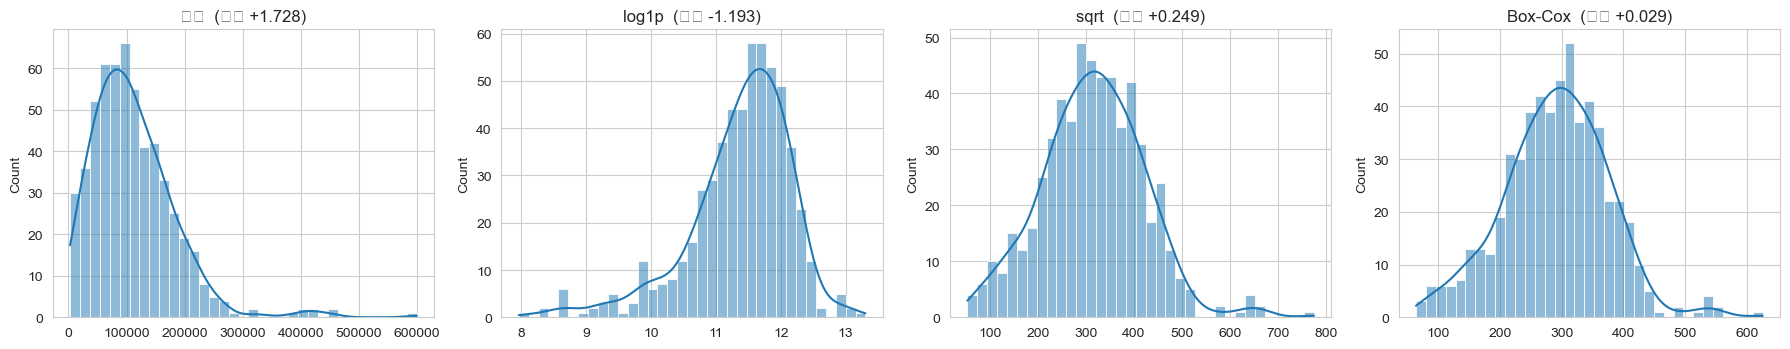

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.6))
for ax, (k, v) in zip(axes, cands.items()):
    sns.histplot(v, kde=True, ax=ax, bins=35)
    ax.set_title(f"{k}  (왜도 {stats.skew(v):+.3f})")
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

**분포 관점 결론**: 원본은 오른쪽으로 치우쳐 있고(왜도 +1.73),
`log1p`는 이를 **과교정**해 왼쪽으로 뒤집는다(−1.19). `sqrt`(+0.25)와 Box-Cox(+0.03)가 대칭에 가깝다.
Box-Cox의 λ가 0.42로 0.5(=sqrt)에 가깝다는 점도 같은 이야기를 한다.

즉 기존에 흔히 쓰이는 "연봉이니까 로그" 라는 선택은 **이 데이터에서는 분포 근거가 없다.**
그렇다면 예측 성능 관점에서는 어떤가? — 이건 §7에서 실제 모델로 측정한다.

---
## 5. 전처리 파이프라인

§1에서 확인한 3.7:1 문제를 여기서 푼다. 원칙은 두 가지다.

1. **희소 범주를 `Other`로 묶는다** — 단, 묶는 기준 빈도는 **훈련 fold에서만** 계산해야 한다.
   전체 데이터로 빈도를 세면 검증 fold의 정보가 새어 들어간다.
2. **모든 전처리를 `Pipeline` 안에 넣는다** — 전체 데이터에 `get_dummies`를 먼저 적용하고
   나중에 split하는 방식(기존 노트북의 패턴)은 누수 위험이 있다.

In [14]:
class RareGrouper(BaseEstimator, TransformerMixin):
    """훈련 fold에서만 빈도를 학습해 희소 범주를 'Other'로 묶는다."""

    def __init__(self, min_count=6):
        self.min_count = min_count

    def fit(self, X, y=None):
        self.keep_ = {c: set(X[c].value_counts()[lambda v: v >= self.min_count].index)
                      for c in X.columns}
        return self

    def transform(self, X):
        X = X.copy()
        for c in X.columns:
            X[c] = X[c].where(X[c].isin(self.keep_[c]), 'Other')
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


HIGH_CARD = ['job_title', 'employee_residence', 'company_location']
NOMINAL   = ['employment_type']
ORDINAL   = ['experience_level', 'company_size']
NUMERIC   = ['work_year', 'remote_ratio']
ORD_CATS  = [['EN', 'MI', 'SE', 'EX'], ['S', 'M', 'L']]


def make_preprocessor(group_rare=True, scale=False):
    hc = [('rare', RareGrouper(6))] if group_rare else []
    hc += [('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]
    num = StandardScaler() if scale else 'passthrough'
    return ColumnTransformer([
        ('hc',  Pipeline(hc), HIGH_CARD),
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False), NOMINAL),
        ('ord', OrdinalEncoder(categories=ORD_CATS), ORDINAL),
        ('num', num, NUMERIC),
    ])


# 타겟과 리키지/중복 컬럼을 분리한다.
# (기존 노트북은 salary_class, salary_class_ 같은 타겟 파생 컬럼을 데이터프레임에
#  그대로 남겨두어, 실수로 피처에 섞이면 정확도가 99%로 튀는 위험이 있었다.
#  여기서는 애초에 X 에 타겟 파생 컬럼을 만들지 않는다.)
y = df['salary_in_usd'].to_numpy()
X = df.drop(columns=['salary', 'salary_currency', 'salary_in_usd'])

print("피처 컬럼:", list(X.columns))
print(f"\n타겟: salary_in_usd  (평균 ${y.mean():,.0f}, 중앙값 ${np.median(y):,.0f})")

피처 컬럼: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

타겟: salary_in_usd  (평균 $110,610, 중앙값 $100,000)


In [15]:
# 그룹핑이 행:피처 비율을 얼마나 개선하는가
for label, gr in [('그룹핑 없음', False), ('1%미만 → Other', True)]:
    p = make_preprocessor(group_rare=gr).fit(X, y)
    n_feat = p.transform(X).shape[1]
    print(f"{label:16s} 피처 {n_feat:3d}개  →  행:피처 = {len(X)/n_feat:5.1f} : 1")

그룹핑 없음           피처 165개  →  행:피처 =   3.4 : 1
1%미만 → Other     피처  50개  →  행:피처 =  11.3 : 1


### 그룹핑은 성능이 아니라 '안정성'을 산다

그룹핑이 실제로 무엇을 개선하는지, 정규화가 없는 모델(OLS)과 있는 모델(Ridge)로 나눠 확인한다.

In [16]:
from sklearn.model_selection import cross_val_score

print(f"{'처리':22s} {'피처':>4s} {'OLS':>16s} {'Ridge(α=10)':>17s}")
for label, gr in [('그룹핑 없이 원-핫', False), ('1%미만 → Other', True)]:
    n_feat = make_preprocessor(group_rare=gr).fit(X, y).transform(X).shape[1]
    ols = cross_val_score(Pipeline([('p', make_preprocessor(gr, True)),
                                    ('m', LinearRegression())]), X, y, cv=CV, scoring='r2')
    rdg = cross_val_score(Pipeline([('p', make_preprocessor(gr, True)),
                                    ('m', Ridge(alpha=10.0))]), X, y, cv=CV, scoring='r2')
    print(f"{label:22s} {n_feat:4d} {ols.mean():8.3f}±{ols.std():.3f} {rdg.mean():10.3f}±{rdg.std():.3f}")

처리                       피처              OLS       Ridge(α=10)
그룹핑 없이 원-핫              165    0.273±0.148      0.503±0.054
1%미만 → Other             50    0.472±0.051      0.494±0.059


**읽어야 할 것**

- **정규화가 없는 OLS에게 그룹핑은 결정적이다.** 그룹핑 없이는 R²가 무너지고 fold 간 표준편차가 0.15에 달한다 —
  즉 **어느 fold에 걸리느냐에 따라 결과가 완전히 달라진다.**
- **Ridge는 그룹핑 여부와 거의 무관하다.** 정규화가 그룹핑과 같은 일(과도한 더미 변수의 영향 억제)을
  이미 해주기 때문이다. → 다중공선성을 VIF로 진단해 변수를 하나씩 쳐내는 것보다 **정규화가 실용적인 해법**이다.
- 그럼에도 그룹핑을 유지하는 이유는 **해석 가능성**이다. 단 한 행만 대표하는 국가 더미의 계수는 해석할 수 없다.

---
## 6. 검증 전략 — 단일 분할 결과를 신뢰하지 않는다

기존 분석은 `train_test_split(random_state=42)` 한 번의 결과로 "R²≈0.43", "정확도 0.68"을 보고했다.
**데이터를 그대로 두고 분할 seed만 바꾸면 그 숫자가 얼마나 달라지는지** 직접 확인한다.

In [17]:
def split_spread(estimator, n_seeds=20):
    scores = []
    for seed in range(n_seeds):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
        est = estimator()
        est.fit(Xtr, ytr)
        scores.append(r2_score(yte, est.predict(Xte)))
    return np.array(scores)

naive_rf = lambda: Pipeline([('p', make_preprocessor(group_rare=False)),
                             ('m', RandomForestRegressor(n_estimators=200,
                                                         random_state=RANDOM_STATE, n_jobs=-1))])
proper   = lambda: Pipeline([('p', make_preprocessor(group_rare=True, scale=True)),
                             ('m', Ridge(alpha=10.0))])

sc_naive  = split_spread(naive_rf)
sc_proper = split_spread(proper)

print(f"{'설계':28s} {'최소':>7s} {'최대':>7s} {'폭':>7s} {'표준편차':>8s}")
for name, sc in [('그룹핑 없는 RF (기존 방식)', sc_naive), ('그룹핑 + Ridge', sc_proper)]:
    print(f"{name:28s} {sc.min():7.3f} {sc.max():7.3f} {sc.max()-sc.min():7.3f} {sc.std():8.3f}")

설계                                최소      최대       폭     표준편차
그룹핑 없는 RF (기존 방식)              0.220   0.648   0.428    0.099
그룹핑 + Ridge                    0.380   0.597   0.217    0.064


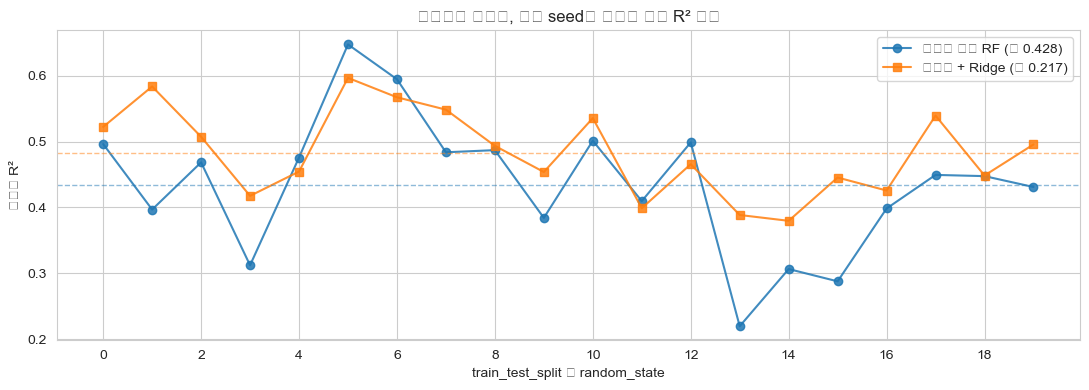

In [18]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sc_naive,  'o-', label=f'그룹핑 없는 RF (폭 {sc_naive.max()-sc_naive.min():.3f})', alpha=.85)
ax.plot(sc_proper, 's-', label=f'그룹핑 + Ridge (폭 {sc_proper.max()-sc_proper.min():.3f})', alpha=.85)
ax.axhline(sc_naive.mean(), ls='--', lw=1, color='C0', alpha=.5)
ax.axhline(sc_proper.mean(), ls='--', lw=1, color='C1', alpha=.5)
ax.set_xlabel('train_test_split 의 random_state'); ax.set_ylabel('테스트 R²')
ax.set_title('데이터는 그대로, 분할 seed만 바꿨을 때의 R² 변동')
ax.set_xticks(range(0, 20, 2)); ax.legend()
plt.tight_layout(); plt.show()

**결론**

- 기존 방식(그룹핑 없는 고차원 모델)은 **분할 seed만 바꿔도 R²가 0.4 이상 요동친다**(위 표의 "폭" 열).
  기존 노트북이 보고한 단일 숫자는 이 분포에서 뽑힌 한 점일 뿐, 모델의 우열을 말해주지 않는다.
- 적절한 설계(그룹핑 + 정규화)로 폭이 줄지만 **사라지지는 않는다.**
  이는 과적합 설계 탓만이 아니라 **565행이라는 데이터 크기 자체의 한계**다.

→ 따라서 이후 모든 성능은 **5-fold 교차검증의 평균 ± 표준편차**로 보고한다.
   표준편차를 생략한 단일 숫자 비교는 하지 않는다.

> 위 두 행은 **모델 종류와 그룹핑 여부가 동시에 다르므로**, 이 표만으로 "고차원이 불안정의 원인"이라고
> 단정할 수는 없다. 원인을 분리한 것은 §5의 실험이다 — 거기서 **모델을 OLS로 고정한 채 그룹핑만 바꾸자
> fold 표준편차가 0.148 → 0.051로 떨어졌다.** 즉 불안정성의 상당 부분은 과도한 피처 수에서 온다.

In [19]:
# 중복행 제거가 교차검증에 준 영향 (§1에서 미룬 측정)
from sklearn.model_selection import cross_val_score

def cv_r2(data):
    yy = data['salary_in_usd'].to_numpy()
    XX = data.drop(columns=['salary', 'salary_currency', 'salary_in_usd'])
    pipe = Pipeline([('p', make_preprocessor(group_rare=True, scale=True)),
                     ('m', Ridge(alpha=10.0))])
    return cross_val_score(pipe, XX, yy, cv=CV, scoring='r2')

with_dup = cv_r2(df_raw)
without  = cv_r2(df)
print(f"중복 포함({len(df_raw)}행): R² = {with_dup.mean():.3f}")
print(f"중복 제거({len(df)}행): R² = {without.mean():.3f}")
print(f"차이: {with_dup.mean()-without.mean():+.3f}")
print("→ 낙관 편향은 존재하지만 미미하다. 제거하는 편이 원칙적으로 옳으나, 과장하지 않는다.")

중복 포함(607행): R² = 0.495
중복 제거(565행): R² = 0.494
차이: +0.001
→ 낙관 편향은 존재하지만 미미하다. 제거하는 편이 원칙적으로 옳으나, 과장하지 않는다.


---
## 7. 모델링 — 베이스라인부터 쌓는다

기존 분석은 곧바로 Random Forest / XGBoost로 갔고, **비교 기준이 없었다.**
"정확도 0.68"이 좋은 것인지 나쁜 것인지 판단할 근거가 없다는 뜻이다.

여기서는 가장 단순한 예측부터 쌓아 올려, **각 단계가 얼마를 벌어주는지** 측정한다.

In [20]:
def mape(yt, yp):
    return np.mean(np.abs((yt - yp) / yt)) * 100

SCORING = {
    'r2'  : 'r2',
    'mae' : make_scorer(mean_absolute_error, greater_is_better=False),
    'mape': make_scorer(mape, greater_is_better=False),
}

results = []

def evaluate(name, estimator):
    cvres = cross_validate(estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    r2, mae, mp = cvres['test_r2'], -cvres['test_mae'], -cvres['test_mape']
    results.append({'모델': name,
                    'R²': r2.mean(), 'R² 표준편차': r2.std(),
                    'MAE': mae.mean(), 'MAPE': mp.mean()})
    print(f"{name:32s} R²={r2.mean():6.3f} ± {r2.std():.3f}   "
          f"MAE=${mae.mean():7,.0f}   MAPE={mp.mean():5.1f}%")
    return r2.mean()

print("모든 전처리는 Pipeline 내부에서 fold별로 fit된다.\n")

모든 전처리는 Pipeline 내부에서 fold별로 fit된다.



In [21]:
# --- 0단계: 아무것도 모를 때의 예측 ---
evaluate('0a. 전체 평균', DummyRegressor(strategy='mean'))
evaluate('0b. 전체 중앙값', DummyRegressor(strategy='median'))

0a. 전체 평균                        R²=-0.001 ± 0.000   MAE=$ 53,348   MAPE=124.4%


0b. 전체 중앙값                       R²=-0.022 ± 0.006   MAE=$ 52,564   MAPE=111.8%


np.float64(-0.02200557700943979)

In [22]:
class GroupMeanBaseline(BaseEstimator):
    """조회 테이블 베이스라인: 몇 개 변수 조합의 훈련 평균을 그대로 예측값으로 쓴다."""

    def __init__(self, keys=('experience_level', 'job_group')):
        self.keys = keys

    @staticmethod
    def _job_group(t):
        t = t.lower()
        for k in ['scientist', 'engineer', 'analyst', 'architect', 'developer']:
            if k in t:
                return k
        if any(k in t for k in ['manager', 'lead', 'head', 'director']):
            return 'manager'
        return 'other'

    def _prep(self, X):
        X = X.copy()
        X['job_group'] = X['job_title'].map(self._job_group)
        return X

    def fit(self, X, y):
        d = self._prep(X)
        d['_y'] = y
        self.map_ = d.groupby(list(self.keys))['_y'].mean()
        self.global_ = float(np.mean(y))
        return self

    def predict(self, X):
        d = self._prep(X)
        idx = pd.MultiIndex.from_frame(d[list(self.keys)])
        p = pd.Series(idx.map(self.map_), dtype=float).to_numpy()
        return np.where(np.isnan(p), self.global_, p)


# --- 1단계: 변수 2개짜리 조회 테이블 ---
evaluate('1a. 경력 × 직무그룹 평균', GroupMeanBaseline())
evaluate('1b. 경력 × 국가 평균',
         GroupMeanBaseline(keys=('experience_level', 'company_location')))

1a. 경력 × 직무그룹 평균                 R²= 0.204 ± 0.120   MAE=$ 44,438   MAPE= 92.1%
1b. 경력 × 국가 평균                   R²= 0.334 ± 0.094   MAE=$ 40,237   MAPE= 86.4%


np.float64(0.33370141361501765)

**여기서 이미 중요한 사실이 나온다.**

`experience_level`과 `company_location` 두 개만으로 만든 조회 테이블이 R² 0.33을 낸다.
그리고 **국가(1b)가 직무(1a)보다 연봉을 훨씬 잘 설명한다** — 같은 직무라도 어느 나라에서 일하는지가
더 결정적이라는 뜻이다. 이후 모델들은 이 기준선을 넘어야 의미가 있다.

In [23]:
# --- 2단계: 정규화 선형모형 ---
ridge_base = Pipeline([('p', make_preprocessor(group_rare=True, scale=True)),
                       ('m', Ridge())])
ridge = RandomizedSearchCV(ridge_base, {'m__alpha': np.logspace(-2, 3, 30)},
                           n_iter=20, cv=CV, scoring='r2',
                           random_state=RANDOM_STATE, n_jobs=-1)

evaluate('2a. Ridge (α 튜닝)', ridge)
evaluate('2b. Ridge + log1p 타겟',
         TransformedTargetRegressor(regressor=ridge, func=np.log1p, inverse_func=np.expm1))
evaluate('2c. Ridge + sqrt 타겟',
         TransformedTargetRegressor(regressor=ridge, func=np.sqrt, inverse_func=np.square))

2a. Ridge (α 튜닝)                 R²= 0.493 ± 0.058   MAE=$ 34,453   MAPE= 54.9%


2b. Ridge + log1p 타겟             R²= 0.500 ± 0.069   MAE=$ 31,879   MAPE= 42.6%


2c. Ridge + sqrt 타겟              R²= 0.509 ± 0.062   MAE=$ 32,344   MAPE= 47.1%


np.float64(0.5086954170769651)

In [24]:
# --- 3단계: 트리 앙상블 (동등한 수준으로 튜닝해서 공정 비교) ---
rf_base = Pipeline([('p', make_preprocessor(group_rare=False, scale=False)),
                    ('m', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf = RandomizedSearchCV(rf_base, {
        'm__n_estimators'    : [200, 400],
        'm__max_depth'       : [None, 6, 10, 16],
        'm__min_samples_leaf': [1, 2, 4, 8],
        'm__max_features'    : ['sqrt', 0.3, 0.6, 1.0],
     }, n_iter=15, cv=CV, scoring='r2',
     random_state=RANDOM_STATE, n_jobs=-1)

evaluate('3a. RandomForest (튜닝)', rf)
evaluate('3b. RandomForest + log1p 타겟',
         TransformedTargetRegressor(regressor=rf, func=np.log1p, inverse_func=np.expm1))

3a. RandomForest (튜닝)            R²= 0.488 ± 0.074   MAE=$ 33,318   MAPE= 50.5%


3b. RandomForest + log1p 타겟      R²= 0.470 ± 0.074   MAE=$ 32,927   MAPE= 48.1%


np.float64(0.4701452840763056)

In [25]:
res = pd.DataFrame(results).set_index('모델')
res_fmt = res.copy()
res_fmt['R²']          = res['R²'].map('{:.3f}'.format) + ' ± ' + res['R² 표준편차'].map('{:.3f}'.format)
res_fmt['MAE']         = res['MAE'].map('${:,.0f}'.format)
res_fmt['MAPE']        = res['MAPE'].map('{:.1f}%'.format)
res_fmt = res_fmt.drop(columns=['R² 표준편차'])
res_fmt

,R²,MAE,MAPE
모델,,,
0a. 전체 평균,-0.001 ± 0.000,"$53,348",124.4%
0b. 전체 중앙값,-0.022 ± 0.006,"$52,564",111.8%
1a. 경력 × 직무그룹 평균,0.204 ± 0.120,"$44,438",92.1%
1b. 경력 × 국가 평균,0.334 ± 0.094,"$40,237",86.4%
2a. Ridge (α 튜닝),0.493 ± 0.058,"$34,453",54.9%
2b. Ridge + log1p 타겟,0.500 ± 0.069,"$31,879",42.6%
2c. Ridge + sqrt 타겟,0.509 ± 0.062,"$32,344",47.1%
3a. RandomForest (튜닝),0.488 ± 0.074,"$33,318",50.5%
3b. RandomForest + log1p 타겟,0.470 ± 0.074,"$32,927",48.1%


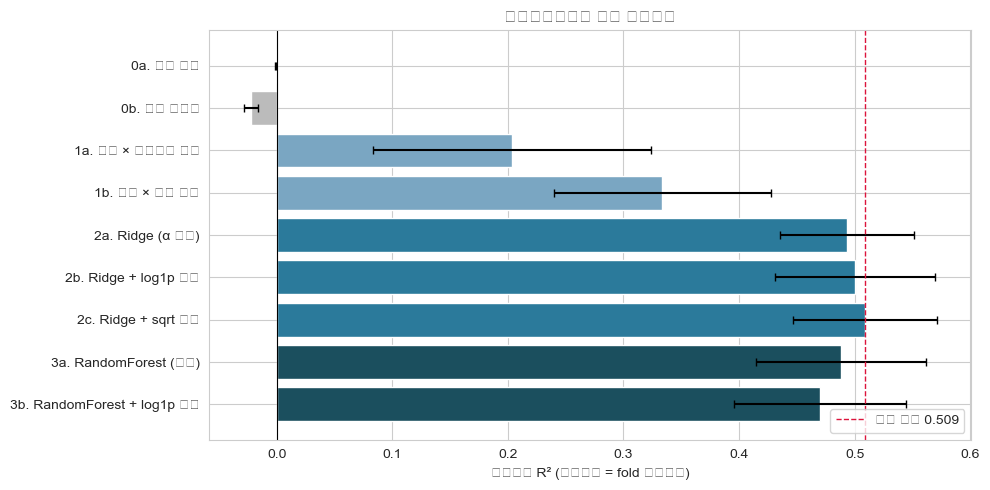

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#bbb' if n.startswith('0') else '#7aa6c2' if n.startswith('1')
          else '#2b7a9b' if n.startswith('2') else '#1b4f5e' for n in res.index]
ax.barh(res.index, res['R²'], xerr=res['R² 표준편차'],
        color=colors, capsize=3)
ax.axvline(0, color='k', lw=.8)
best = res['R²'].max()
ax.axvline(best, ls='--', color='crimson', lw=1, label=f'최고 성능 {best:.3f}')
ax.set_xlabel('교차검증 R² (오차막대 = fold 표준편차)')
ax.set_title('베이스라인부터 최종 모델까지')
ax.invert_yaxis(); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

### 모델링 결론

**(1) 정규화 선형모형이 트리 앙상블과 대등하다.**
Ridge와 RandomForest의 차이는 fold 표준편차(±0.06) 안에 들어간다 — **통계적으로 구분되지 않는다.**
성능이 같다면 **더 단순하고 계수 해석이 가능한 Ridge를 택할 이유가 있다.**
기존 분석이 곧장 트리 앙상블로 직행한 데에는 근거가 없었다.

> ⚠️ **이 결론을 얻는 과정에서 저지른 실수를 기록해 둔다.**
> 처음 비교했을 때는 "Ridge가 RF를 크게 앞선다"는 결과가 나왔다. 그런데 그때 **RF는 튜닝하지 않은 기본값**이었고,
> Ridge만 하이퍼파라미터를 탐색한 불공정 비교였다. 위처럼 양쪽을 같은 수준으로 튜닝하자 차이는 사라졌다.
> **모델 비교는 양쪽을 동등하게 튜닝한 뒤에만 의미가 있다.**

**(2) 타겟 변환의 효과는 지표에 따라 다르다 — 그래서 어떤 지표를 볼지 먼저 정해야 한다.**
`sqrt`가 R²에서 근소하게 앞서고, `log1p`가 MAE·MAPE(상대오차)에서 앞선다.
두 모델의 R² 차이는 fold 표준편차 안이라 **R²로는 우열을 가릴 수 없다.**
§4에서 본 대로 분포 대칭성은 `sqrt`가 낫지만, **예측 목적에서 `log1p`를 쓰는 근거는 "상대오차 최적화"이지
"정규분포화"가 아니다.** 연봉 오차는 본질적으로 곱셈적이므로(연봉 2억에서 1천만원 차이와 3천만원에서 1천만원 차이는
의미가 다르다) 상대오차를 기준으로 삼는 것이 타당하다. → **§8에서 `log1p`를 채택 모델로 고정한다.**

**(3) 2변수 조회 테이블이 최고 모델 성능의 상당 부분에 도달한다.**
정교한 파이프라인이 실제로 더한 가치를 정직하게 인식해야 한다.

---
## 8. 성능을 정직하게 해석한다

R²만 보고하면 실제보다 좋아 보인다. **이 모델이 실무에서 어느 정도인지** 번역한다.

In [27]:
# 채택 모델을 명시적으로 고정한다 (지표마다 1등이 달라 자동 선택은 혼란을 부른다)
ADOPTED = '2b. Ridge + log1p 타겟'

print("지표별 1등이 다르다:")
print(f"  R²   최고 : {res['R²'].idxmax()}  ({res['R²'].max():.3f})")
print(f"  MAE  최고 : {res['MAE'].idxmin()}  (${res['MAE'].min():,.0f})")
print(f"  MAPE 최고 : {res['MAPE'].idxmin()}  ({res['MAPE'].min():.1f}%)")
print()
r2_gap = res['R²'].max() - res.loc[ADOPTED, 'R²']
print(f"R² 1등(sqrt)과 채택 모델(log1p)의 차이는 {r2_gap:.3f} 로 fold 표준편차(±{res.loc[ADOPTED,'R² 표준편차']:.3f}) 안이다.")
print("→ R²로는 구분되지 않으므로, 상대오차(MAPE)가 뚜렷이 나은 log1p 를 채택한다.")
print()

best = res.loc[ADOPTED]
print(f"[채택] {ADOPTED}")
print(f"  R²   = {best['R²']:.3f} ± {best['R² 표준편차']:.3f}")
print(f"  MAE  = ${best['MAE']:,.0f}")
print(f"  MAPE = {best['MAPE']:.1f}%")
print()
print(f"참고 · 실제 연봉 평균 = ${y.mean():,.0f}, 중앙값 = ${np.median(y):,.0f}")
print()
print(f'즉 "R² {best["R²"]:.2f}"는 실무 언어로:')
print(f'  → 연봉을 평균 {best["MAPE"]:.0f}% 오차로 맞힌다는 뜻이다.')
print(f'  → 연봉 $100,000 인 사람을 대략 ${100000*(1-best["MAPE"]/100):,.0f} ~ ${100000*(1+best["MAPE"]/100):,.0f} 로 추정한다.')

지표별 1등이 다르다:
  R²   최고 : 2c. Ridge + sqrt 타겟  (0.509)
  MAE  최고 : 2b. Ridge + log1p 타겟  ($31,879)
  MAPE 최고 : 2b. Ridge + log1p 타겟  (42.6%)

R² 1등(sqrt)과 채택 모델(log1p)의 차이는 0.009 로 fold 표준편차(±0.069) 안이다.
→ R²로는 구분되지 않으므로, 상대오차(MAPE)가 뚜렷이 나은 log1p 를 채택한다.

[채택] 2b. Ridge + log1p 타겟
  R²   = 0.500 ± 0.069
  MAE  = $31,879
  MAPE = 42.6%

참고 · 실제 연봉 평균 = $110,610, 중앙값 = $100,000

즉 "R² 0.50"는 실무 언어로:
  → 연봉을 평균 43% 오차로 맞힌다는 뜻이다.
  → 연봉 $100,000 인 사람을 대략 $57,367 ~ $142,633 로 추정한다.


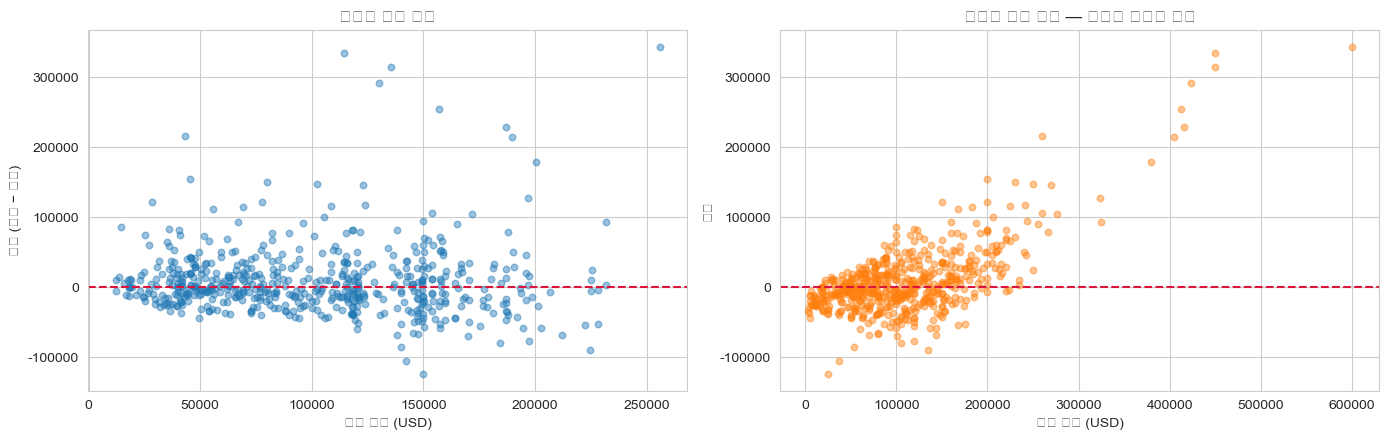

,건수,평균실제,평균예측,평균잔차
구간,,,,
최하위 20%,115,30861.0,44259.0,-13398.0
하위,111,68736.0,75347.0,-6611.0
중간,113,100040.0,99951.0,89.0
상위,116,137624.0,132079.0,5545.0
최상위 20%,110,218611.0,157480.0,61131.0


In [28]:
# 잔차 분석: "정규성 확인"이 아니라 "어느 구간에서 체계적으로 틀리는가"를 본다
from sklearn.model_selection import cross_val_predict

best_model = TransformedTargetRegressor(regressor=ridge, func=np.log1p, inverse_func=np.expm1)
pred = cross_val_predict(best_model, X, y, cv=CV, n_jobs=-1)
resid = y - pred

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(pred, resid, alpha=.45, s=22)
axes[0].axhline(0, color='crimson', ls='--')
axes[0].set_xlabel('예측 연봉 (USD)'); axes[0].set_ylabel('잔차 (실제 − 예측)')
axes[0].set_title('예측값 대비 잔차')

order = np.argsort(y)
axes[1].scatter(y[order], resid[order], alpha=.45, s=22, color='C1')
axes[1].axhline(0, color='crimson', ls='--')
axes[1].set_xlabel('실제 연봉 (USD)'); axes[1].set_ylabel('잔차')
axes[1].set_title('실제값 대비 잔차 — 고연봉 구간을 보라')

plt.tight_layout(); plt.show()

# 구간별 편향
bins = pd.qcut(y, 5, labels=['최하위 20%','하위','중간','상위','최상위 20%'])
bias = pd.DataFrame({'실제': y, '예측': pred, '잔차': resid, '구간': bins})
bias.groupby('구간', observed=True).agg(
    건수=('실제','size'), 평균실제=('실제','mean'),
    평균예측=('예측','mean'), 평균잔차=('잔차','mean')).round(0)

**잔차가 말해주는 것**

모델은 **최상위 연봉 구간을 체계적으로 과소 예측하고, 최하위 구간을 과대 예측한다** —
평균 쪽으로 끌어당기는 전형적인 회귀 축소(shrinkage) 패턴이다.

이는 §3에서 남겨둔 고연봉 10건과 직결된다. 그 값들을 지웠다면 이 편향은 **보이지 않았을 뿐 사라지지 않았을 것**이다.
지금은 최소한 **모델의 한계가 어디에 있는지 눈에 보인다.**

---
## 9. 해석 — 무엇이 연봉을 움직이는가

트리 모델의 `feature_importances_`는 **크기만 알려주고 방향을 알려주지 않는다.**
"국가가 중요하다"까지만 말할 수 있고 "어느 방향으로"는 말할 수 없다.

§7에서 Ridge가 트리 앙상블과 대등한 성능을 냈으므로, **표준화된 Ridge 계수를 그대로 해석**하면
크기와 방향을 동시에 읽을 수 있다.

단, 계수의 **크기**를 서로 비교하려면 모든 입력이 같은 척도여야 한다.
전처리기의 `StandardScaler`는 수치형 두 개에만 걸려 있으므로, 아래에서는 `ColumnTransformer` 뒤에
스케일러를 한 번 더 두어 **더미·순서형까지 전부 표준화한 뒤** 계수를 비교한다.

In [29]:
# 채택 모델이 실제로 고른 alpha 를 확인한다 (§7의 RandomizedSearchCV 결과)
ridge.fit(X, np.log1p(y))
best_alpha = ridge.best_params_['m__alpha']
print(f"채택 모델이 선택한 alpha = {best_alpha:.4f}")

채택 모델이 선택한 alpha = 8.5317


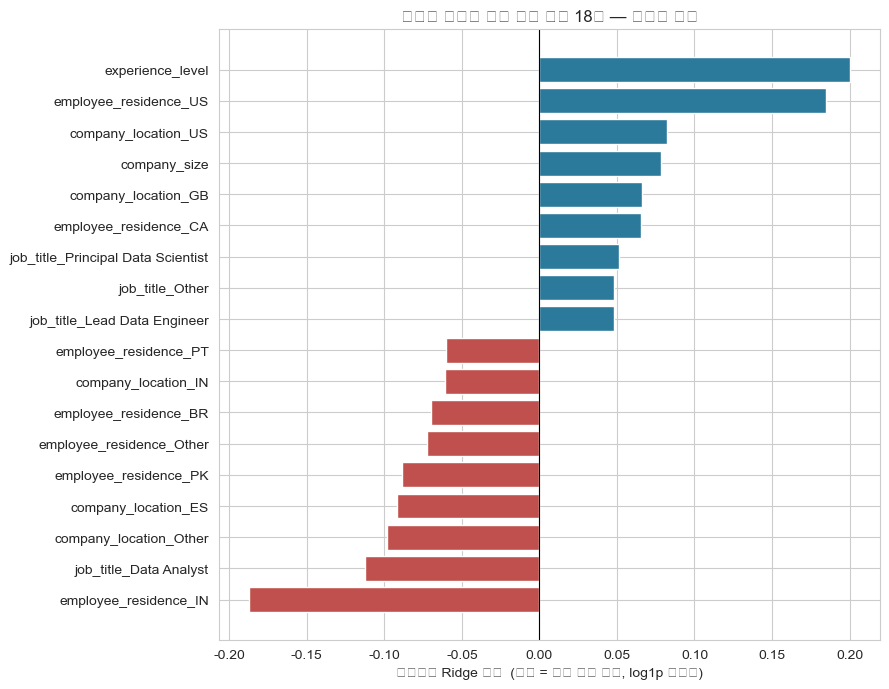

In [30]:
# 계수 크기를 비교하려면 모든 열이 같은 척도여야 한다.
# make_preprocessor 의 StandardScaler 는 수치형(work_year, remote_ratio) 에만 걸리므로,
# ColumnTransformer 뒤에 스케일러를 한 번 더 두어 더미·순서형까지 전부 표준화한다.
interp = Pipeline([('p',  make_preprocessor(group_rare=True, scale=True)),
                   ('sc', StandardScaler()),
                   ('m',  Ridge(alpha=best_alpha))])
interp.fit(X, np.log1p(y))

names = interp.named_steps['p'].get_feature_names_out()
coefs = interp.named_steps['m'].coef_
coef_s = (pd.Series(coefs, index=[n.split('__', 1)[-1] for n in names])
            .sort_values(key=abs, ascending=False).head(18)
            .sort_values())

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_s.index, coef_s.values,
        color=['#c0504d' if v < 0 else '#2b7a9b' for v in coef_s.values])
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('표준화된 Ridge 계수  (양수 = 연봉 상승 방향, log1p 스케일)')
ax.set_title('연봉에 영향을 주는 요인 상위 18개 — 크기와 방향')
plt.tight_layout(); plt.show()

In [31]:
top = coef_s.reindex(coef_s.abs().sort_values(ascending=False).index).head(10)
print("영향력 상위 10개 (계수 부호 포함)\n")
for k, v in top.items():
    direction = '↑ 상승' if v > 0 else '↓ 하락'
    print(f"  {k:42s} {v:+.4f}  {direction}")

영향력 상위 10개 (계수 부호 포함)

  experience_level                           +0.2003  ↑ 상승
  employee_residence_IN                      -0.1874  ↓ 하락
  employee_residence_US                      +0.1851  ↑ 상승
  job_title_Data Analyst                     -0.1125  ↓ 하락
  company_location_Other                     -0.0983  ↓ 하락
  company_location_ES                        -0.0918  ↓ 하락
  employee_residence_PK                      -0.0886  ↓ 하락
  company_location_US                        +0.0821  ↑ 상승
  company_size                               +0.0784  ↑ 상승
  employee_residence_Other                   -0.0725  ↓ 하락


**해석**

- **경력 수준(`experience_level`)이 단일 요인으로 가장 강하다**(+0.20). EN→MI→SE→EX로 올라갈수록 연봉이 오른다.
- 그 다음이 **거주 국가**다. 미국 거주(+0.19)는 상승, 인도(−0.19)·파키스탄(−0.09) 등은 하락 방향으로 뚜렷하다.
  §7에서 "경력 × 국가" 조회 테이블이 R² 0.33을 냈던 것과 정확히 같은 이야기다.
- 직무는 상대적으로 약하다. `job_title_Data Analyst`(−0.11)가 눈에 띄는 정도이며,
  §7에서 직무 기반 베이스라인(0.204)이 국가 기반(0.334)보다 약했던 것과 일치한다.
- 이 계수들은 `log1p` 스케일이므로 **대략 "몇 % 차이"로 읽을 수 있다.**

> **표준화를 고치자 순위가 바뀌었다.** 처음에는 전처리기의 `StandardScaler`가 수치형 두 개에만 적용된 상태로
> 계수를 비교했고, 그때 `experience_level`은 6위로 나왔다. 0~3 범위의 순서형 변수를 0/1 더미와 나란히 놓고
> 크기를 비교했기 때문에 **과소평가된 것**이다. 모든 열을 표준화하자 1위로 올라왔다.
> — 계수 크기를 비교할 때 척도를 통일해야 하는 이유를 보여주는 사례다.

> **주의 1 — 인과가 아니다.** 이것은 상관에 근거한 설명이다. "미국으로 이직하면 연봉이 오른다"가 아니라
> "이 데이터에서 미국 근무자의 연봉이 높게 관측된다"까지가 정확한 서술이다.
> 표본의 절반 이상이 미국(§1)이라는 편중도 함께 고려해야 한다.
>
> **주의 2 — 이진 변수의 표준화 계수는 희소성을 반영한다.** 더미 변수를 표준화하면 해당 범주가 드물수록
> 표준편차가 작아 계수가 커 보인다. §5에서 1% 미만 범주를 이미 `Other`로 묶었지만,
> 여전히 흔한 범주와 드문 범주의 계수를 1:1로 비교할 때는 이 점을 감안해야 한다.

---
## 10. 결론과 한계

### 최종 결과

- **채택 모델**: Ridge 회귀 + `log1p` 타겟 변환, 희소 범주 그룹핑 (§8에서 근거 명시)
- **성능**: 교차검증 R² 0.500 ± 0.069, **MAE \$31,879, MAPE 42.6%**
- `sqrt` 변환이 R² 0.509로 근소하게 높지만 **fold 표준편차 안의 차이**라 우열을 가릴 수 없어,
  상대오차(MAPE)가 뚜렷이 나은 `log1p`를 택했다.
- 트리 앙상블(RandomForest, R² 0.488 ± 0.074)과도 성능 차이가 통계적으로 유의하지 않아,
  **해석 가능한 선형 모형을 택했다.**

### 이 재검증으로 바뀐 것

| 항목 | 기존 분석 | 재검증 후 |
| --- | --- | --- |
| 문제 프레이밍 | 3-class 분류 | **회귀** (임계값 임의성 제거) |
| `salary_currency` | "리키지라서 제외" | **중복 변수라서 제외** (리키지 아님) |
| 고연봉 10건 | IQR로 삭제 | **유지** (실존 고위직, 설명 대상) |
| 범주형 처리 | 그대로 원-핫 (164피처) | **희소 범주 그룹핑** (50피처) |
| 성능 보고 | 단일 분할 숫자 | **교차검증 평균 ± 표준편차** |
| 비교 기준 | 없음 | **베이스라인 사다리** |
| 성능 서술 | R²만 | **MAPE 병기 (43% 오차)** |

### 한계 — 정직하게 남긴다

1. **데이터가 작다(565행).** §6에서 본 대로 분할에 따라 R²가 0.2 이상 흔들린다.
   여기서 보고한 값도 5-fold 평균일 뿐이며, fold 표준편차만 ±0.07이다.
2. **표본이 미국에 편중(55~58%)되어 있다.** 사실상 "미국 데이터 직무 연봉 모델"에 가깝고,
   다른 지역으로의 일반화는 보장되지 않는다.
3. **MAPE 42.6%는 실무에 바로 쓰기 어려운 수준이다.** 연봉을 결정하는 핵심 변수
   (구체적 기술 스택, 회사 규모 상세, 산업, 학력·연차 수치)가 데이터에 없기 때문이며,
   이는 모델링 기법이 아니라 **데이터 수집 단계에서 풀어야 할 문제**다.
4. **미검증 항목**: SHAP 기반 해석, Target/Frequency Encoding, `remote_ratio`의 수치형/범주형 처리 차이는
   이 노트북에서 측정하지 않았다. (`CLAUDE_PROPOSED.md`에 `[미검증]`으로 표시)

### 이 프로젝트에서 얻은 것

성능 숫자보다, **자신의 과거 분석을 검증해 결론을 뒤집은 과정**이 이 프로젝트의 핵심이다.
특히 "리키지라고 적어둔 변수가 사실 리키지가 아니었다", "튜닝을 한쪽만 하고 모델 우열을 판단했다"는
두 오류는 **측정을 통해서만 드러났다.** 문서에 적힌 설명과 코드가 실제로 하는 일은 다를 수 있고,
그 간극은 직접 돌려봐야 보인다.